# Import Library

In [ ]:
pip install pmdarima

In [ ]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet
from prophet.plot import plot_plotly
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.ar_model import AutoReg,ARResults
nlag = 40
from sklearn.metrics import mean_absolute_percentage_error
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# Read Data

In [ ]:
df = pd.read_csv ("https://raw.githubusercontent.com/nikensaras/Data-Analyst-Project/refs/heads/main/Forecasting/forecasting.csv")

In [ ]:
df.head(10)

,id,date,category,qty,year,month,day_of_month,day_of_week,week_of_year,quarter,is_weekend,day_name,is_payday_period,event_harbolnas,event_ramadan,inflation_rate,usd_idr_rate,fuel_price,consumer_confidence_index,avg_price,revenue,is_holiday,event_eid,category_group,lag_1_qty,lag_7_qty,rolling_avg_7_qty,lag_1_revenue,lag_7_revenue,rolling_avg_7_revenue
0,19272,1/11/2013,AUTOMOTIVE,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,0,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
1,953040,6/20/2014,AUTOMOTIVE,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.36,12440.0,8500.0,112.0,25000.0,NaN,0,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
2,1452,1/1/2013,AUTOMOTIVE,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,1,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
3,26400,1/15/2013,AUTOMOTIVE,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,0,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
4,5016,1/3/2013,AUTOMOTIVE,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,0,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
5,8580,1/5/2013,AUTOMOTIVE,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,1,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
6,10362,1/6/2013,AUTOMOTIVE,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,1,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
7,58476,2/2/2013,AUTOMOTIVE,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12069.0,6500.0,108.8,25000.0,NaN,1,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
8,12144,1/7/2013,AUTOMOTIVE,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,0,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
9,13926,1/8/2013,AUTOMOTIVE,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,0,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN


# Info Data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55572 entries, 0 to 55571
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         55572 non-null  int64  
 1   date                       55572 non-null  object 
 2   category                   55572 non-null  object 
 3   qty                        55572 non-null  float64
 4   year                       0 non-null      float64
 5   month                      0 non-null      float64
 6   day_of_month               0 non-null      float64
 7   day_of_week                0 non-null      float64
 8   week_of_year               0 non-null      float64
 9   quarter                    0 non-null      float64
 10  is_weekend                 0 non-null      float64
 11  day_name                   0 non-null      float64
 12  is_payday_period           0 non-null      float64
 13  event_harbolnas            0 non-null      flo

In [ ]:
df.describe()

,id,qty,year,month,day_of_month,day_of_week,week_of_year,quarter,is_weekend,day_name,is_payday_period,event_harbolnas,event_ramadan,inflation_rate,usd_idr_rate,fuel_price,consumer_confidence_index,avg_price,revenue,is_holiday,event_eid,lag_1_qty,lag_7_qty,rolling_avg_7_qty,lag_1_revenue,lag_7_revenue,rolling_avg_7_revenue
count,5.557200e+04,55572.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55572.000000,55572.000000,55572.000000,55572.000000,55572.00000,55572.000000,0.0,55572.000000,55572.000000,0.0,0.0,0.0,0.0,0.0,0.0
mean,1.501021e+06,477.613744,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.087292,5.483688,12916.139549,7292.695962,114.92696,31363.636364,NaN,0.293943,0.032660,NaN,NaN,NaN,NaN,NaN,NaN
std,8.662894e+05,1538.413443,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.282265,2.524774,528.398062,768.210449,3.95312,17915.480829,NaN,0.455570,0.177748,NaN,NaN,NaN,NaN,NaN,NaN
min,1.452000e+03,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,3.020000,12039.000000,6500.000000,108.50000,12000.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,7.512365e+05,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,3.350000,12339.000000,6550.000000,111.40000,25000.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.501021e+06,22.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,3.610000,13229.000000,7400.000000,114.40000,25000.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,2.250806e+06,281.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,8.360000,13366.000000,7650.000000,118.00000,25000.000000,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
max,3.000590e+06,35279.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,8.380000,13629.000000,8500.000000,122.60000,95000.000000,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isnull().sum()

,0
id,0
date,0
category,0
qty,0
year,55572
month,55572
day_of_month,55572
day_of_week,55572
week_of_year,55572
quarter,55572


In [ ]:
df.duplicated().sum()

np.int64(0)

# Urutkan Data

In [ ]:
df = df.sort_values(['category','date'])

In [ ]:
df.head()

,id,date,category,qty,year,month,day_of_month,day_of_week,week_of_year,quarter,is_weekend,day_name,is_payday_period,event_harbolnas,event_ramadan,inflation_rate,usd_idr_rate,fuel_price,consumer_confidence_index,avg_price,revenue,is_holiday,event_eid,category_group,lag_1_qty,lag_7_qty,rolling_avg_7_qty,lag_1_revenue,lag_7_revenue,rolling_avg_7_revenue
2,1452,1/1/2013,AUTOMOTIVE,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.38,12039.0,6500.0,108.5,25000.0,NaN,1,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
357,650100,1/1/2014,AUTOMOTIVE,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.36,12265.0,8500.0,110.5,25000.0,NaN,1,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
1007,1298748,1/1/2015,AUTOMOTIVE,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.35,13189.0,7400.0,113.5,25000.0,NaN,1,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
1365,1947396,1/1/2016,AUTOMOTIVE,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.02,13208.0,6550.0,116.5,25000.0,NaN,1,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN
1724,2597826,1/1/2017,AUTOMOTIVE,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.61,13306.0,7650.0,120.5,25000.0,NaN,1,0,Automotive,NaN,NaN,NaN,NaN,NaN,NaN


# Feature Engineer

## Date

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
df['year'] = df['year'].fillna(df['date'].dt.year).astype(int)

In [ ]:
df['month'] = df['month'].fillna(df['date'].dt.month).astype(int)

In [ ]:
df['day_of_month'] = df['day_of_month'].fillna(df['date'].dt.day).astype(int)

In [ ]:
df['day_of_week'] = df['day_of_week'].fillna(df['date'].dt.dayofweek).astype(int)

In [ ]:
df['week_of_year'] = df['week_of_year'].fillna(df['date'].dt.isocalendar().week).astype(int)

In [ ]:
df['quarter'] = df['quarter'].fillna(df['date'].dt.quarter).astype(int)

In [ ]:
df['is_weekend'] = df['date'].dt.dayofweek.isin([5,6]).astype(int)

In [ ]:
df['day_name'] = df['day_name'].fillna(df['date'].dt.day_name())

## Revenue

In [ ]:
df['revenue'] = df['avg_price'] * df['qty']

## Event

In [ ]:
df['is_payday_period'] = (df['date'].dt.day >= 25) | (df['date'].dt.day <=5).astype(int)

In [ ]:
df['event_harbolnas'] = (
    ((df['month'] == 1) & (df['date'].dt.day == 1)) |
    ((df['month'] == 2) & (df['date'].dt.day == 2)) |
    ((df['month'] == 3) & (df['date'].dt.day == 3)) |
    ((df['month'] == 4) & (df['date'].dt.day == 4)) |
    ((df['month'] == 5) & (df['date'].dt.day == 5)) |
    ((df['month'] == 6) & (df['date'].dt.day == 6)) |
    ((df['month'] == 7) & (df['date'].dt.day == 7)) |
    ((df['month'] == 8) & (df['date'].dt.day == 8)) |
    ((df['month'] == 9) & (df['date'].dt.day == 9)) |
    ((df['month'] == 10) & (df['date'].dt.day == 10)) |
    ((df['month'] == 11) & (df['date'].dt.day == 11)) |
    ((df['month'] == 12) & (df['date'].dt.day == 12))
).astype(int)

## LAG

In [ ]:
df['lag_1_qty'] = df.groupby('category')['qty'].shift(1)
df['lag_7_qty'] = df.groupby('category')['qty'].shift(7)

In [ ]:
df['lag_1_revenue'] = df.groupby('category')['revenue'].shift(1)
df['lag_7_revenue'] = df.groupby('category')['revenue'].shift(7)

In [ ]:
df['rolling_avg_7_qty'] = (df.groupby('category')['qty'].transform(lambda x: x.shift(1).rolling(7).mean()))
df['rolling_avg_7_revenue'] = (df.groupby('category')['revenue'].transform(lambda x: x.shift(1).rolling(7).mean()))

In [ ]:
df.tail()

,id,date,category,qty,year,month,day_of_month,day_of_week,week_of_year,quarter,is_weekend,day_name,is_payday_period,event_harbolnas,event_ramadan,inflation_rate,usd_idr_rate,fuel_price,consumer_confidence_index,avg_price,revenue,is_holiday,event_eid,category_group,lag_1_qty,lag_7_qty,rolling_avg_7_qty,lag_1_revenue,lag_7_revenue,rolling_avg_7_revenue
54882,2394710,2016-09-08,SEAFOOD,14.0,2016,9,8,3,36,3,0,Thursday,False,0,0,3.02,13368.0,6550.0,118.9,25000.0,350000.0,0,0,Food & Beverage,11.0,11.0,12.000000,275000.0,275000.0,300000.000000
53785,448766,2013-09-09,SEAFOOD,11.0,2013,9,9,0,37,3,0,Monday,False,1,0,8.38,12279.0,6500.0,110.9,25000.0,275000.0,0,0,Food & Beverage,14.0,14.0,12.428571,350000.0,350000.0,310714.285714
54148,1097414,2014-09-09,SEAFOOD,23.0,2014,9,9,1,37,3,0,Tuesday,False,1,0,8.36,12545.0,8500.0,112.9,25000.0,575000.0,0,0,Food & Beverage,11.0,6.0,12.000000,275000.0,150000.0,300000.000000
54518,1746062,2015-09-09,SEAFOOD,13.0,2015,9,9,2,37,3,0,Wednesday,False,1,0,3.35,13509.0,7400.0,115.9,25000.0,325000.0,0,0,Food & Beverage,23.0,5.0,14.428571,575000.0,125000.0,360714.285714
54883,2396492,2016-09-09,SEAFOOD,25.0,2016,9,9,4,36,3,0,Friday,False,1,0,3.02,13368.0,6550.0,118.9,25000.0,625000.0,0,0,Food & Beverage,13.0,29.0,15.571429,325000.0,725000.0,389285.714286


In [ ]:
df.loc[df['lag_7_qty'].isna(), ['date', 'qty', 'lag_1_qty', 'lag_7_qty', 'rolling_avg_7_qty']].head(10)

,date,qty,lag_1_qty,lag_7_qty,rolling_avg_7_qty
2,2013-01-01,0.0,NaN,NaN,NaN
357,2014-01-01,0.0,0.0,NaN,NaN
1007,2015-01-01,0.0,0.0,NaN,NaN
1365,2016-01-01,0.0,0.0,NaN,NaN
1724,2017-01-01,0.0,0.0,NaN,NaN
579,2013-01-10,2.0,0.0,NaN,NaN
368,2014-01-10,1.0,2.0,NaN,NaN
55386,2013-01-01,0.0,NaN,NaN,NaN
2288,2014-01-01,0.0,0.0,NaN,NaN
2638,2015-01-01,0.0,0.0,NaN,NaN


In [ ]:
df=df.fillna(0)

# EDA

## Heatmap

In [ ]:
# heatmap korelasi
cols = [
    'qty',
    'revenue',
    'avg_price',
    'fuel_price',
    'usd_idr_rate',
    'inflation_rate',
    'consumer_confidence_index',
    'usd_idr_rate',
    'fuel_price',
    'is_payday_period',
    'event_harbolnas',
    'lag_1_qty',
    'lag_7_qty',
    'rolling_avg_7_qty'
]

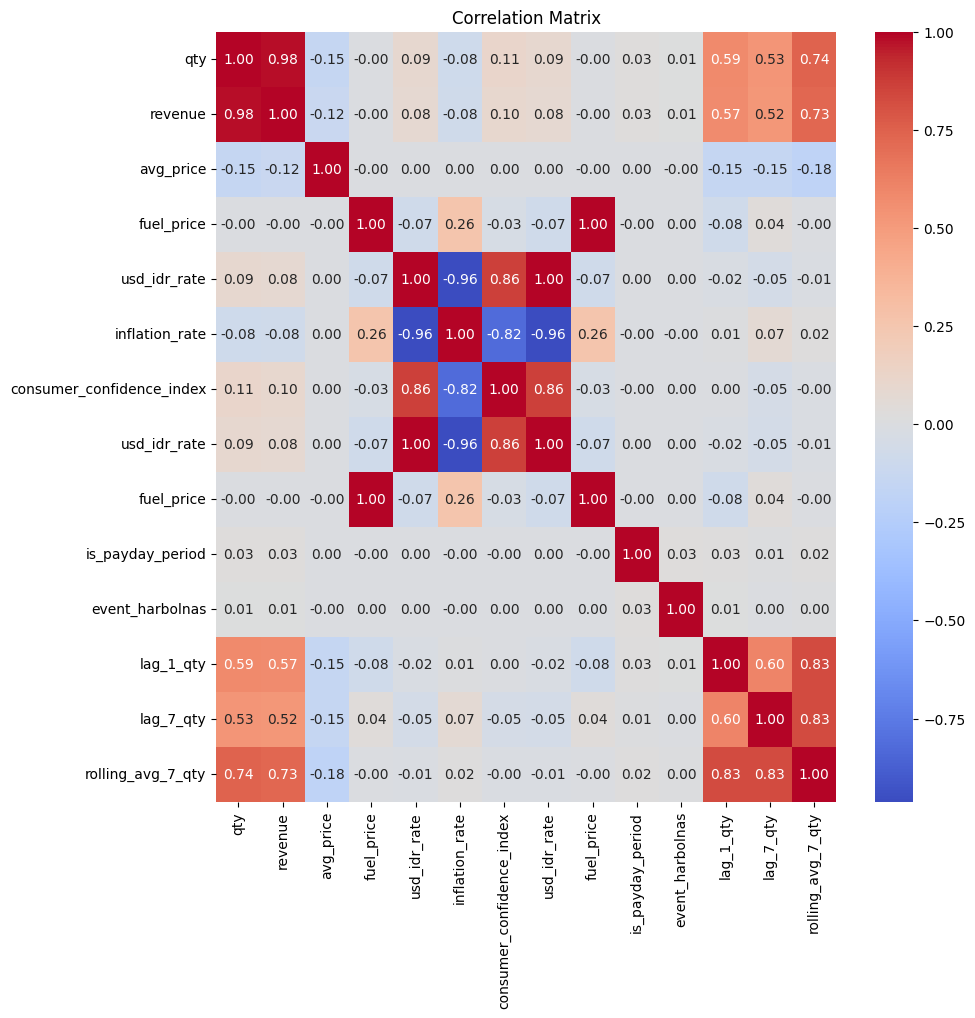

In [ ]:
corr = df[cols].corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
correlation = df['qty'].corr(df['revenue'])

print(f"Correlation between qty and revenue: {correlation:.4f}")

Correlation between qty and revenue: 0.9832


Interpretation
+1 = perfect positive relationship
0 = no linear relationship
-1 = perfect negative relationship

Indicate a strong positive correlation, meaning that when quantity sold increases, revenue tends to increase as well.

In [ ]:
correlation = df['consumer_confidence_index'].corr(df['usd_idr_rate'])

print(f"Correlation between cci and idr: {correlation:.4f}")

Correlation between cci and idr: 0.8622


In [ ]:
corr_cols = [
    'qty',
    'lag_1_qty',
    'lag_7_qty',
    'rolling_avg_7_qty'
]

print(df[corr_cols].corr())

                        qty  lag_1_qty  lag_7_qty  rolling_avg_7_qty
qty                1.000000   0.585481   0.530209           0.742131
lag_1_qty          0.585481   1.000000   0.603497           0.825174
lag_7_qty          0.530209   0.603497   1.000000           0.825454
rolling_avg_7_qty  0.742131   0.825174   0.825454           1.000000


In [ ]:
df_ml = df.copy()

# Machine Learning

In [ ]:
monthly_quantity = (df_ml.groupby(pd.Grouper(key='date', freq='MS'))['qty'].sum())

In [ ]:
monthly_quantity = monthly_quantity[monthly_quantity.index < '2017-08-01']

In [ ]:
monthly_revenue = (df_ml.groupby(pd.Grouper(key='date', freq='MS'))['revenue'].sum())

In [ ]:
monthly_revenue = monthly_revenue[monthly_revenue.index < '2017-08-01']

Quantity

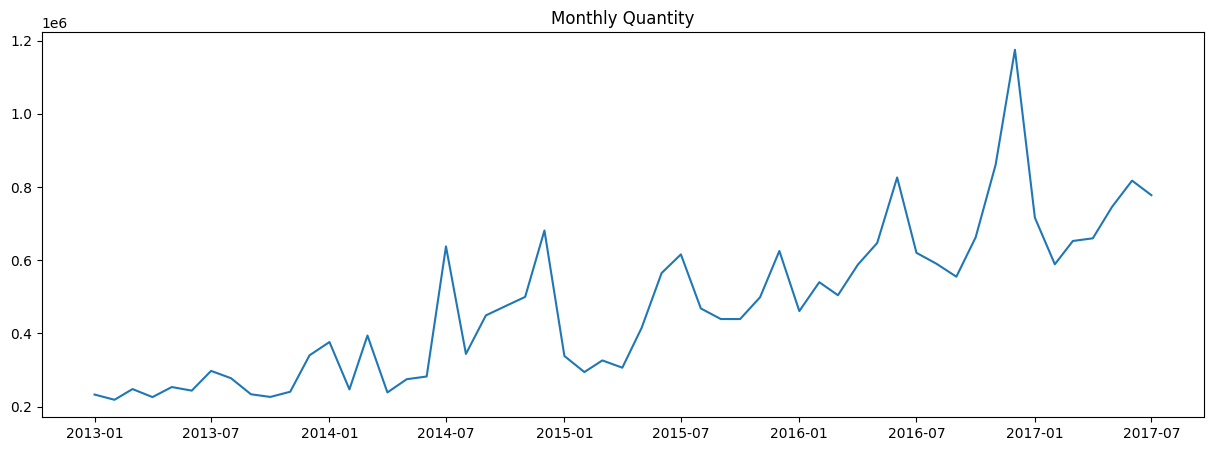

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(monthly_quantity)
plt.title('Monthly Quantity')
plt.show()

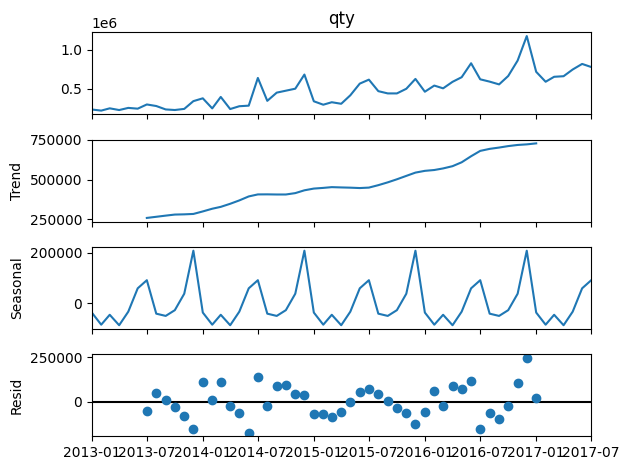

In [ ]:
decomp = seasonal_decompose(
    monthly_quantity,
    model = 'additive',
    period=12)
decomp.plot()
plt.show()

Revenue

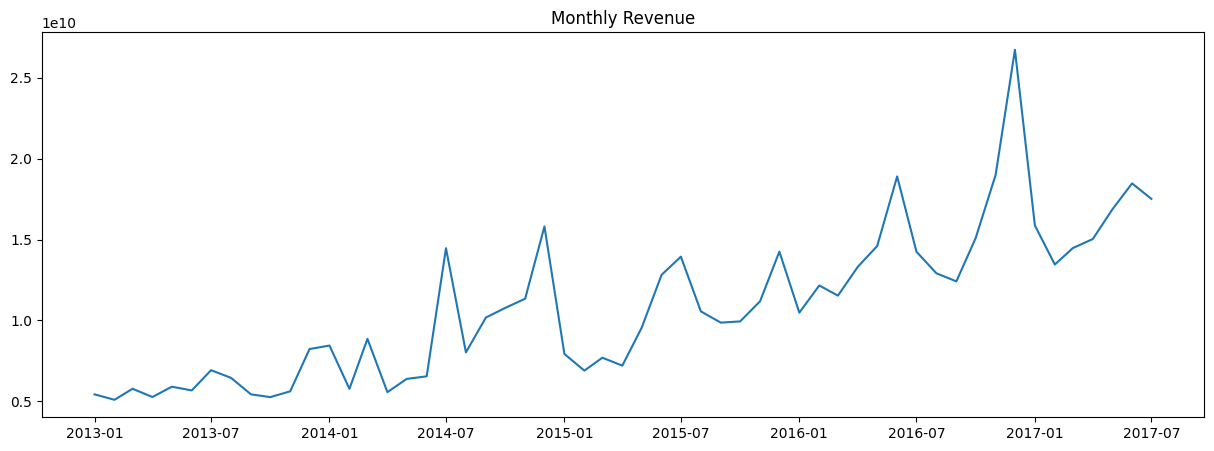

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(monthly_revenue)
plt.title('Monthly Revenue')
plt.show()

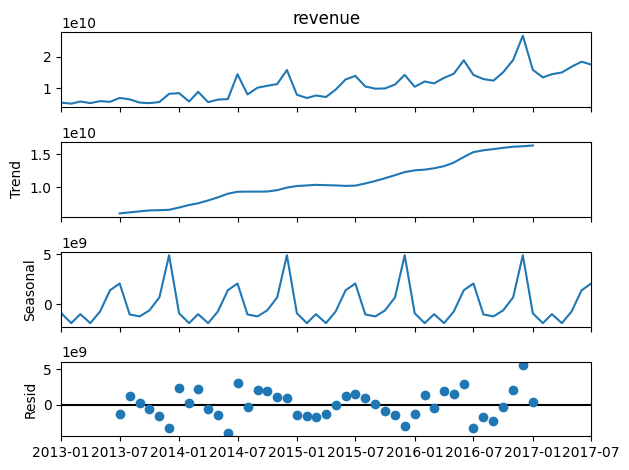

In [ ]:
decomp = seasonal_decompose(
    monthly_revenue,
    model = 'additive',
    period=12)
decomp.plot()
plt.show()

# Split

In [ ]:
train_size = int(len(monthly_quantity) * 0.8)
train_qty = monthly_quantity[:train_size]
test_qty = monthly_quantity[train_size:]

In [ ]:
train_size = int(len(monthly_revenue) * 0.8)
train_revenue = monthly_revenue[:train_size]
test_revenue = monthly_revenue[train_size:]

# Forecasting

## ARIMA

Quantity

In [ ]:
auto_model_qty = auto_arima(
train_qty,
seasonal=False,
trace= True)
print(auto_model_qty.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1134.442, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1129.661, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1124.941, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1132.647, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1127.473, Time=0.04 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1132.077, Time=0.05 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1125.388, Time=0.02 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 0.552 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   44
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -559.471
Date:                Wed, 17 Jun 2026   AIC                

In [ ]:
arma_model_qty = ARIMA(train_qty, order=(0, 1, 1))
arma_fit_qty = arma_model_qty.fit()

In [ ]:
arma_pred_qty = arma_fit_qty.forecast(len(test_qty))

In [ ]:
arma_future_qty = arma_fit_qty.forecast(steps=12)

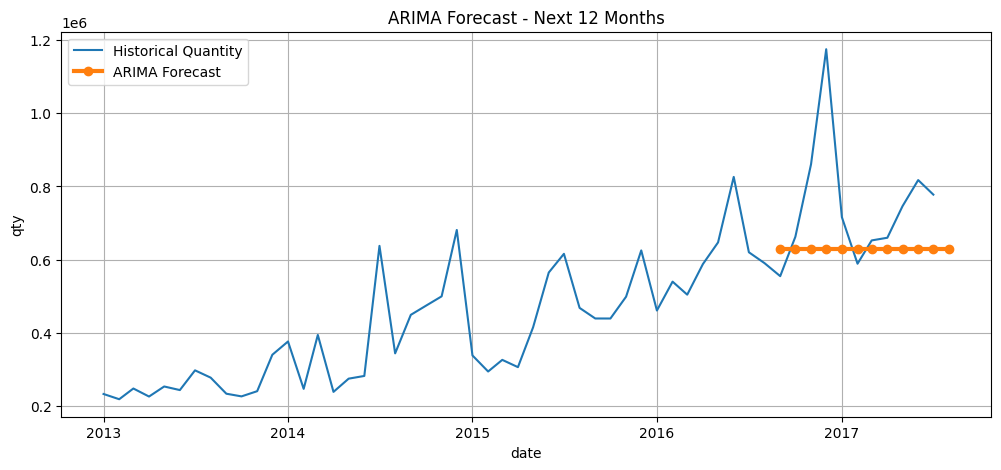

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_quantity.index,
    monthly_quantity.values,
    label='Historical Quantity')
plt.plot(
    arma_future_qty.index,
    arma_future_qty.values,
    marker='o',
    linewidth=3,
    label='ARIMA Forecast')
plt.title('ARIMA Forecast - Next 12 Months')
plt.xlabel('date')
plt.ylabel('qty')
plt.legend()
plt.grid(True)
plt.show()

Revenue

In [ ]:
auto_model_revenue = auto_arima(
train_revenue,
seasonal=False,
trace= True)
print(auto_model_revenue.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1996.623, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1992.498, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1987.151, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1994.801, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1990.164, Time=0.05 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1995.136, Time=0.05 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1987.761, Time=0.02 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 0.455 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   44
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -990.575
Date:                Wed, 17 Jun 2026   AIC                

In [ ]:
arma_model_revenue = ARIMA(train_revenue, order=(0, 1, 1))
arma_fit_revenue = arma_model_revenue.fit()

In [ ]:
arma_pred_revenue = arma_fit_revenue.forecast(len(test_revenue))

In [ ]:
arma_future_revenue = arma_fit_revenue.forecast(steps=12)

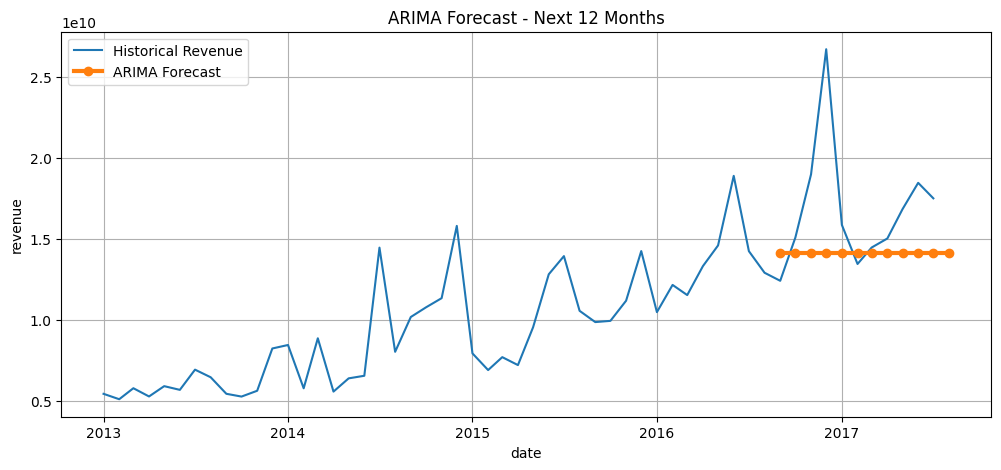

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    label='Historical Revenue')
plt.plot(
    arma_future_revenue.index,
    arma_future_revenue.values,
    marker='o',
    linewidth=3,
    label='ARIMA Forecast')
plt.title('ARIMA Forecast - Next 12 Months')
plt.xlabel('date')
plt.ylabel('revenue')
plt.legend()
plt.grid(True)
plt.show()

## SARIMA

Quantity

In [ ]:
auto_arima(train_qty,seasonal=True, m=12, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.19 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1134.442, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1126.752, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1122.057, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1132.647, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1124.941, Time=0.03 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=1122.065, Time=0.12 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=1123.271, Time=0.13 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=1125.666, Time=0.05 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=1123.610, Time=0.30 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=1128.640, Time=0.05 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=1124.075, Time=0.08 sec
 ARIMA(0,1,2)(0,0,1)[12] intercept   : AIC=1126.179, Time=0.07 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1123.431, Time=0.06 sec
 ARIMA(1,1,2)(0,0,1)[12]

ARIMA(order=(0, 1, 1), scoring_args={}, seasonal_order=(0, 0, 1, 12),
      suppress_warnings=True, with_intercept=False)

In [ ]:
sarima_model_qty = SARIMAX(train_qty,
                       order=(0, 1, 1),
                       seasonal_order=(0, 0, 2, 6))
sarima_fit_qty = sarima_model_qty.fit()

In [ ]:
sarima_pred_qty = sarima_fit_qty.forecast(len(test_qty))

In [ ]:
sarima_future_qty = sarima_fit_qty.forecast(12)

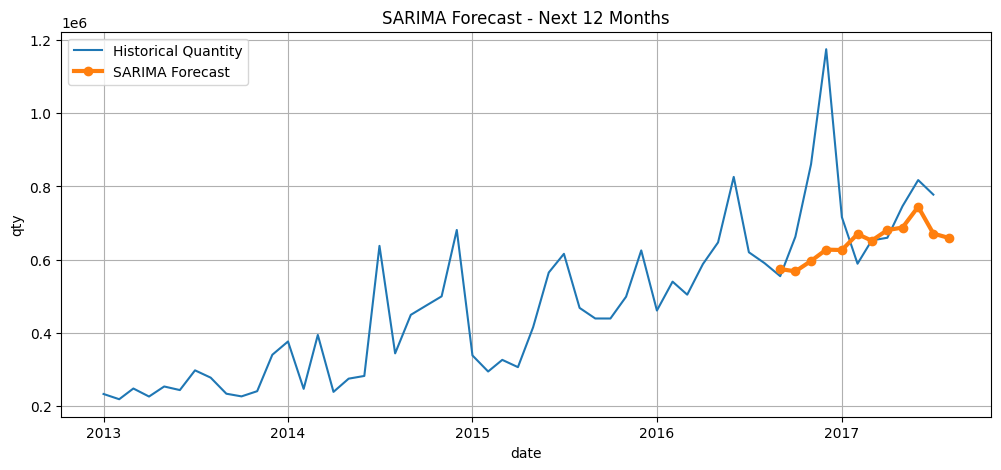

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_quantity.index,
    monthly_quantity.values,
    label='Historical Quantity')
plt.plot(
    sarima_future_qty.index,
    sarima_future_qty.values,
    marker='o',
    linewidth=3,
    label='SARIMA Forecast')
plt.title('SARIMA Forecast - Next 12 Months')
plt.xlabel('date')
plt.ylabel('qty')
plt.legend()
plt.grid(True)
plt.show()

Revenue

In [ ]:
auto_arima(train_revenue,seasonal=True, m=6, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[6] intercept   : AIC=inf, Time=0.36 sec
 ARIMA(0,1,0)(0,0,0)[6] intercept   : AIC=1996.623, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[6] intercept   : AIC=1993.830, Time=0.04 sec
 ARIMA(0,1,1)(0,0,1)[6] intercept   : AIC=1988.907, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[6]             : AIC=1994.801, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[6] intercept   : AIC=1987.151, Time=0.04 sec
 ARIMA(0,1,1)(1,0,0)[6] intercept   : AIC=1989.135, Time=0.05 sec
 ARIMA(0,1,1)(1,0,1)[6] intercept   : AIC=1986.945, Time=0.15 sec
 ARIMA(0,1,1)(2,0,1)[6] intercept   : AIC=1988.880, Time=0.22 sec
 ARIMA(0,1,1)(1,0,2)[6] intercept   : AIC=1987.277, Time=0.11 sec
 ARIMA(0,1,1)(0,0,2)[6] intercept   : AIC=1985.359, Time=0.09 sec
 ARIMA(0,1,0)(0,0,2)[6] intercept   : AIC=1991.712, Time=0.06 sec
 ARIMA(1,1,1)(0,0,2)[6] intercept   : AIC=1987.573, Time=0.11 sec
 ARIMA(0,1,2)(0,0,2)[6] intercept   : AIC=1989.782, Time=0.11 sec
 ARIMA(1,1,0)(0,0,2)[6] intercept   : 

ARIMA(order=(0, 1, 1), scoring_args={}, seasonal_order=(0, 0, 2, 6),
      suppress_warnings=True, with_intercept=False)

In [ ]:
sarima_model_revenue = SARIMAX(train_revenue,
                       order=(0, 1, 1),
                       seasonal_order=(0, 0, 2, 6))
sarima_fit_revenue = sarima_model_revenue.fit()

In [ ]:
sarima_pred_revenue = sarima_fit_revenue.forecast(len(test_revenue))

In [ ]:
sarima_future_revenue = sarima_fit_revenue.forecast(12)

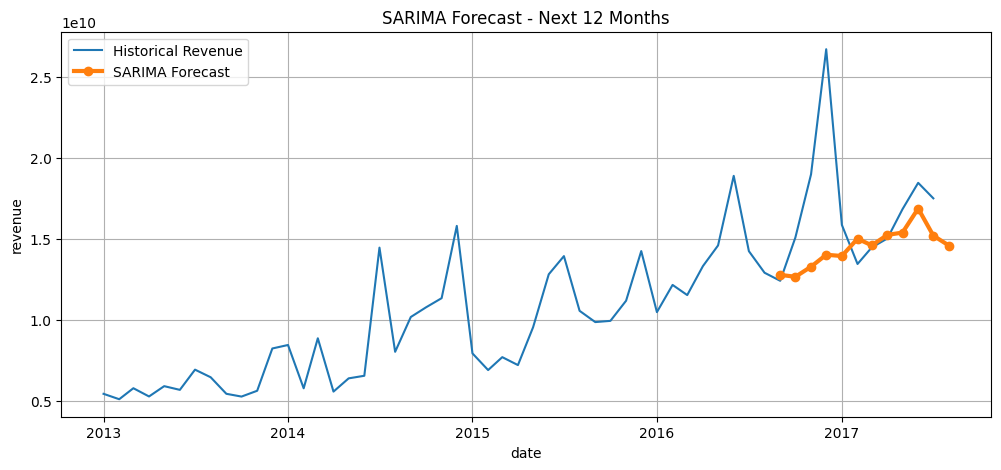

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    label='Historical Revenue')
plt.plot(
    sarima_future_revenue.index,
    sarima_future_revenue.values,
    marker='o',
    linewidth=3,
    label='SARIMA Forecast')
plt.title('SARIMA Forecast - Next 12 Months')
plt.xlabel('date')
plt.ylabel('revenue')
plt.legend()
plt.grid(True)
plt.show()

## Holt Winter

Quantity

In [ ]:
hw_model_qty = ExponentialSmoothing(train_qty, trend='add',
                                seasonal='add', seasonal_periods=12)
hw_fit_qty = hw_model_qty.fit()
hw_pred_qty = hw_fit_qty.forecast(len(test_qty))
hw_future_qty = hw_fit_qty.forecast(12)

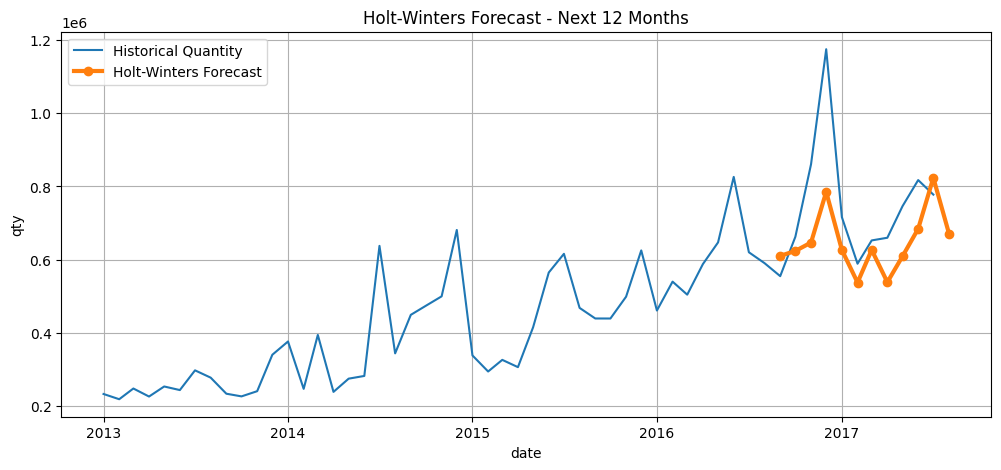

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_quantity.index,
    monthly_quantity.values,
    label='Historical Quantity')
plt.plot(
    hw_future_qty.index,
    hw_future_qty.values,
    marker='o',
    linewidth=3,
    label='Holt-Winters Forecast')
plt.title('Holt-Winters Forecast - Next 12 Months')
plt.xlabel('date')
plt.ylabel('qty')
plt.legend()
plt.grid(True)
plt.show()

Revenue

In [ ]:
hw_model_revenue = ExponentialSmoothing(train_revenue, trend='add',
                                seasonal='add', seasonal_periods=12)
hw_fit_revenue = hw_model_revenue.fit()
hw_pred_revenue = hw_fit_revenue.forecast(len(test_revenue))
hw_future_revenue = hw_fit_revenue.forecast(12)

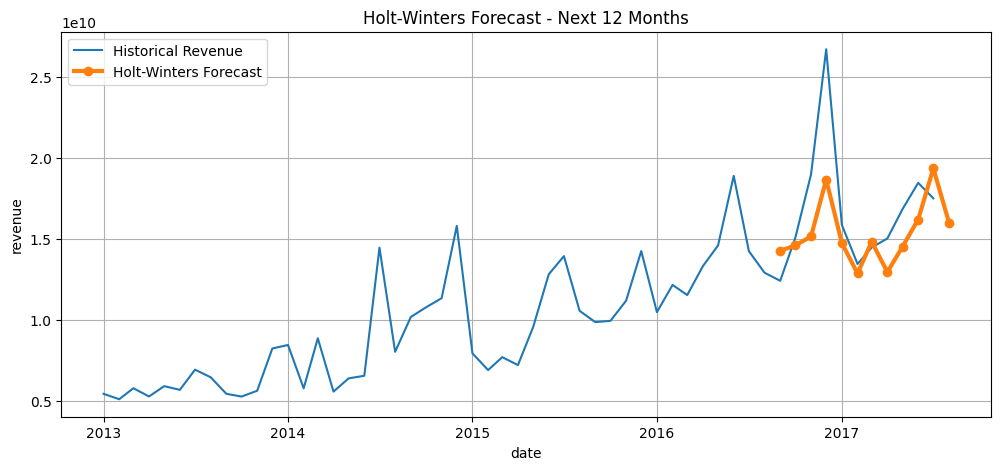

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    label='Historical Revenue')
plt.plot(
    hw_future_revenue.index,
    hw_future_revenue.values,
    marker='o',
    linewidth=3,
    label='Holt-Winters Forecast')
plt.title('Holt-Winters Forecast - Next 12 Months')
plt.xlabel('date')
plt.ylabel('revenue')
plt.legend()
plt.grid(True)
plt.show()

## Prophet

Quantity

In [ ]:
prophet_train_qty = train_qty.reset_index()
prophet_train_qty.columns = ['ds', 'y']
prophet_model_qty = Prophet(seasonality_mode='multiplicative',
                        seasonality_prior_scale=15,
                        yearly_seasonality=True)
prophet_model_qty.fit(prophet_train_qty)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future_test_qty = prophet_model_qty.make_future_dataframe(
    periods=len(test_qty), freq='MS')
forecast_test_qty = prophet_model_qty.predict(future_test_qty)
prophet_pred_qty = forecast_test_qty[['ds', 'yhat']].tail(len(test_qty))
prophet_pred_qty = pd.Series(prophet_pred_qty['yhat']. values,index=test_qty.index)

In [ ]:
prophet_full_qty = monthly_quantity.reset_index()
prophet_full_qty.columns = ['ds', 'y']
prophet_final_qty = Prophet(
    seasonality_mode='multiplicative',
    seasonality_prior_scale=15,
    yearly_seasonality=True)
prophet_final_qty.fit(prophet_full_qty)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future_qty = prophet_final_qty.make_future_dataframe(
    periods=12, freq='MS')
forecast_qty = prophet_final_qty.predict(future_qty)
prophet_future_qty = (forecast_qty[['ds', 'yhat']].tail(12).set_index('ds'))

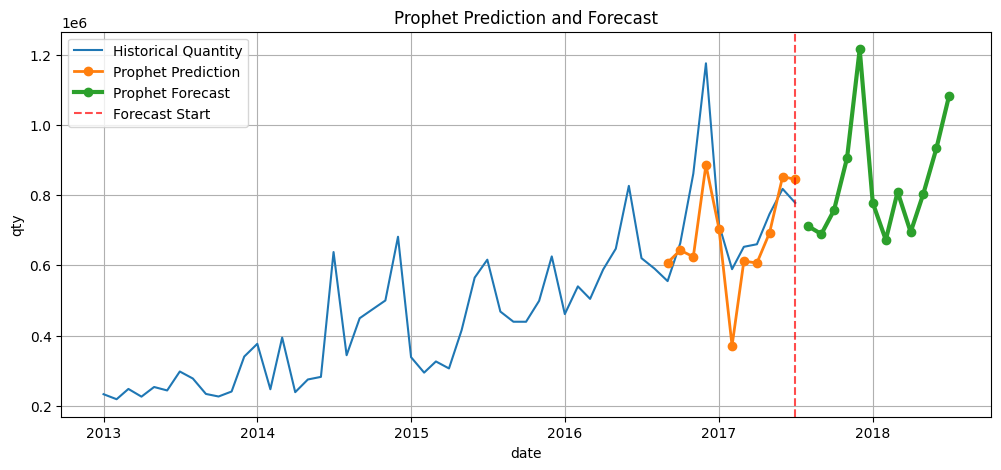

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_quantity.index,
    monthly_quantity.values,
    label='Historical Quantity')

plt.plot(
    prophet_pred_qty.index,
    prophet_pred_qty.values,
    marker='o',
    linewidth=2,
    label='Prophet Prediction')

plt.plot(
    prophet_future_qty.index,
    prophet_future_qty['yhat'],
    marker='o',
    linewidth=3,
    label='Prophet Forecast')

plt.axvline(
    monthly_quantity.index[-1],
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Forecast Start')

plt.title('Prophet Prediction and Forecast')
plt.xlabel('date')
plt.ylabel('qty')
plt.legend()
plt.grid(True)
plt.show()

Revenue

In [ ]:
prophet_train_revenue = train_revenue.reset_index()
prophet_train_revenue.columns = ['ds', 'y']
prophet_model_revenue = Prophet(seasonality_mode='multiplicative',
                        seasonality_prior_scale=15,
                        yearly_seasonality=True)
prophet_model_revenue.fit(prophet_train_revenue)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future_test_revenue = prophet_model_revenue.make_future_dataframe(
    periods=len(test_revenue), freq='MS')
forecast_test_revenue = prophet_model_revenue.predict(future_test_revenue)
prophet_pred_revenue = forecast_test_revenue[['ds', 'yhat']].tail(len(test_revenue))
prophet_pred_revenue = pd.Series(prophet_pred_revenue['yhat']. values,index=test_revenue.index)

In [ ]:
prophet_full_revenue = monthly_revenue.reset_index()
prophet_full_revenue.columns = ['ds', 'y']
prophet_final_revenue = Prophet(
    seasonality_mode='multiplicative',
    seasonality_prior_scale=15,
    yearly_seasonality=True)
prophet_final_revenue.fit(prophet_full_revenue)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future_revenue = prophet_final_revenue.make_future_dataframe(
    periods=12, freq='MS')
forecast_revenue = prophet_final_revenue.predict(future_revenue)
prophet_future_revenue = (forecast_revenue[['ds', 'yhat']].tail(12).set_index('ds'))

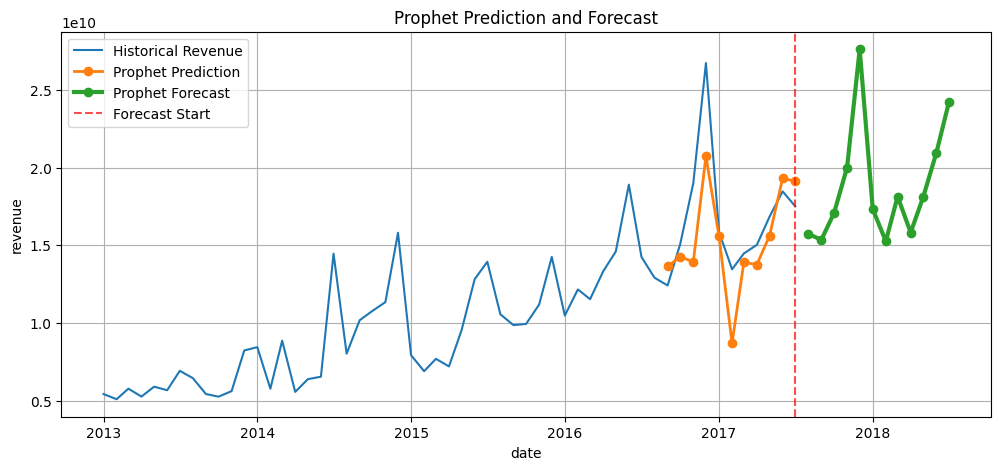

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    label='Historical Revenue')

plt.plot(
    prophet_pred_revenue.index,
    prophet_pred_revenue.values,
    marker='o',
    linewidth=2,
    label='Prophet Prediction')

plt.plot(
    prophet_future_revenue.index,
    prophet_future_revenue['yhat'],
    marker='o',
    linewidth=3,
    label='Prophet Forecast')

plt.axvline(
    monthly_revenue.index[-1],
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Forecast Start')

plt.title('Prophet Prediction and Forecast')
plt.xlabel('date')
plt.ylabel('revenue')
plt.legend()
plt.grid(True)
plt.show()

# Evaluasi Model

Quantity

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error
def evaluate(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    ) * 100

    return mae, rmse, mape
results = []

results.append(
    ["ARIMA", *evaluate(test_qty, arma_pred_qty)]
)

results.append(
    ["SARIMA", *evaluate(test_qty, sarima_pred_qty)]
)

results.append(
    ["Holt Winter", *evaluate(test_qty, hw_pred_qty)]
)

results.append(
    ["Prophet", *evaluate(test_qty, prophet_pred_qty)]
)

results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "MAPE"
    ]
)

results

Revenue

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error
def evaluate(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    ) * 100

    return mae, rmse, mape
results = []

results.append(
    ["ARIMA", *evaluate(test_revenue, arma_pred_revenue)]
)

results.append(
    ["SARIMA", *evaluate(test_revenue, sarima_pred_revenue)]
)

results.append(
    ["Holt Winter", *evaluate(test_revenue, hw_pred_revenue)]
)

results.append(
    ["Prophet", *evaluate(test_revenue, prophet_pred_revenue)]
)

results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "MAPE"
    ]
)

results

# Grafik

Quantity

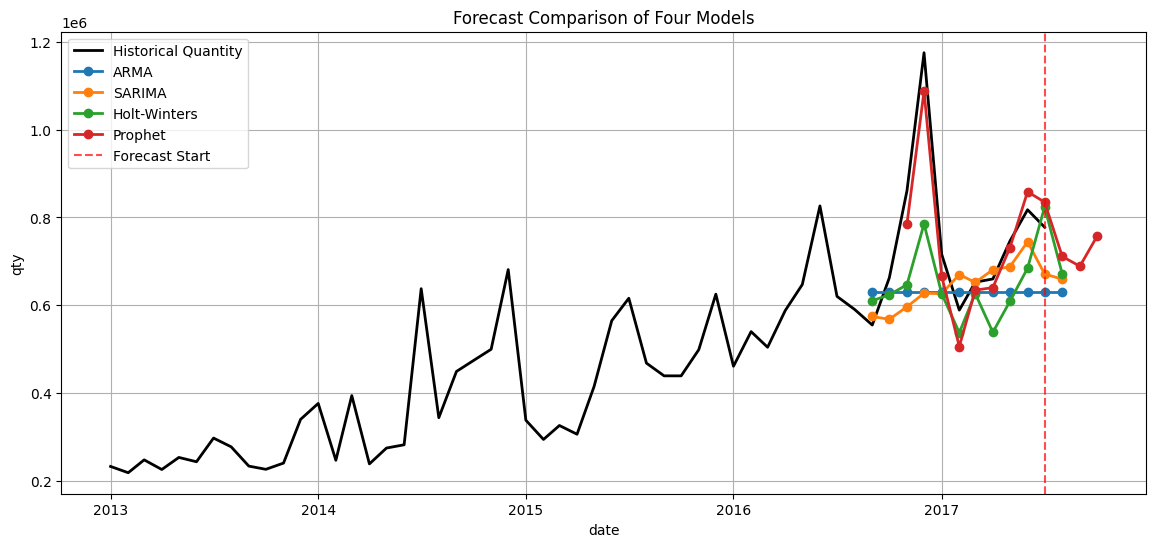

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(
    monthly_quantity.index,
    monthly_quantity.values,
    color='black',
    linewidth=2,
    label='Historical Quantity'
)

# ARIMA
plt.plot(
    arma_future_qty.index,
    arma_future_qty.values,
    marker='o',
    linewidth=2,
    label='ARMA'
)

# SARIMA
plt.plot(
    sarima_future_qty.index,
    sarima_future_qty.values,
    marker='o',
    linewidth=2,
    label='SARIMA'
)

# Holt-Winters
plt.plot(
    hw_future_qty.index,
    hw_future_qty.values,
    marker='o',
    linewidth=2,
    label='Holt-Winters'
)

# Prophet
plt.plot(
    prophet_future_qty.index,
    prophet_future_qty['yhat'],
    marker='o',
    linewidth=2,
    label='Prophet'
)

plt.axvline(
    monthly_quantity.index[-1],
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Forecast Start'
)

plt.title('Forecast Comparison of Four Models')
plt.xlabel('date')
plt.ylabel('qty')
plt.legend()
plt.grid(True)

plt.show()

Revenue

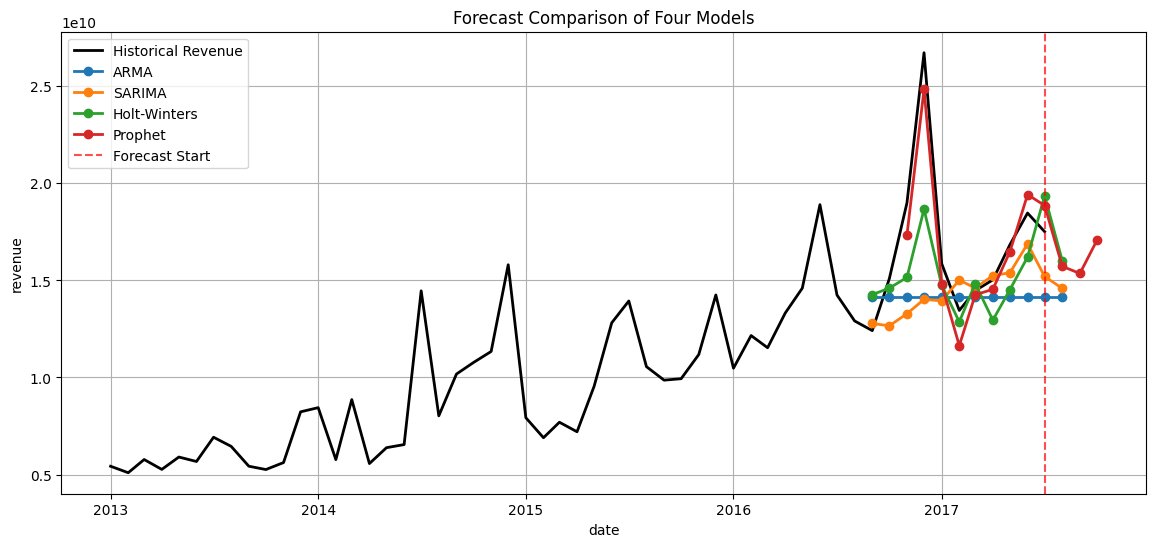

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    color='black',
    linewidth=2,
    label='Historical Revenue'
)

# ARIMA
plt.plot(
    arma_future_revenue.index,
    arma_future_revenue.values,
    marker='o',
    linewidth=2,
    label='ARMA'
)

# SARIMA
plt.plot(
    sarima_future_revenue.index,
    sarima_future_revenue.values,
    marker='o',
    linewidth=2,
    label='SARIMA'
)

# Holt-Winters
plt.plot(
    hw_future_revenue.index,
    hw_future_revenue.values,
    marker='o',
    linewidth=2,
    label='Holt-Winters'
)

# Prophet
plt.plot(
    prophet_future_revenue.index,
    prophet_future_revenue['yhat'],
    marker='o',
    linewidth=2,
    label='Prophet'
)

plt.axvline(
    monthly_revenue.index[-1],
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Forecast Start'
)

plt.title('Forecast Comparison of Four Models')
plt.xlabel('date')
plt.ylabel('revenue')
plt.legend()
plt.grid(True)

plt.show()

# Data Forecast Final

In [ ]:
qty_full = monthly_quantity.reset_index()
qty_full.columns = ['ds','y']

prophet_final_qty = Prophet()

prophet_final_qty.fit(
    qty_full
)

future_qty = prophet_final_qty.make_future_dataframe(
    periods=12,
    freq='MS'
)

prophet_future_qty = prophet_final_qty.predict(
    future_qty
)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
hw_final_revenue = ExponentialSmoothing(
    monthly_revenue,
    trend='mul',
    seasonal='add',
    seasonal_periods=12
)

hw_final_fit_revenue = hw_final_revenue.fit()

hw_final_future_revenue = hw_final_fit_revenue.forecast(12)

In [ ]:
future_dates = pd.date_range(
    start=monthly_revenue.index[-1]
          + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

hw_final_future_revenue.index = future_dates

In [ ]:
forecast_final = pd.DataFrame({
    'Date':
        prophet_future_qty['ds']
        .tail(12)
        .values,

    'Forecast_Qty':
        prophet_future_qty['yhat']
        .tail(12)
        .round(0)
        .values,

    'Forecast_Revenue':
        hw_final_future_revenue
        .round(0)
        .values
})

forecast_final

,Date,Forecast_Qty,Forecast_Revenue
0,2017-08-01,735655.0,1.831838e+10
1,2017-09-01,721037.0,1.868341e+10
2,2017-10-01,759902.0,1.908050e+10
3,2017-11-01,846274.0,1.999081e+10
4,2017-12-01,1043713.0,2.353518e+10
5,2018-01-01,801671.0,1.985147e+10
6,2018-02-01,745035.0,1.942466e+10
7,2018-03-01,827046.0,2.077822e+10
8,2018-04-01,764517.0,2.035230e+10
9,2018-05-01,825005.0,2.198502e+10


In [ ]:
forecast_final.to_csv(
    'final_forecasting.csv',
    index=False
)